In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score, davies_bouldin_score
import datetime as dt
from sklearn.decomposition import PCA
import time
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


In [36]:
# 1. Verileri Yükle
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

# 2. Birleştirme (Merging) İşlemleri
# Önce siparişlerle ürün detaylarını birleştirelim
df = pd.merge(orders, order_items, on='order_id', how='inner')

# Sonra müşteri bilgilerini ekleyelim
df = pd.merge(df, customers, on='customer_id', how='inner')

# Son olarak ürün kategorilerini ekleyelim (Hikayeleştirme için)
df = pd.merge(df, products[['product_id', 'product_category_name']], on='product_id', how='left')

# 3. İlk Bakış
print(f"Toplam Satır Sayısı: {df.shape[0]}")
print(f"Toplam Sütun Sayısı: {df.shape[1]}")
print(f"Veri Seti Boyutu: {df.shape}")
print("\nİlk 5 Satır:")
df.head()

Toplam Satır Sayısı: 112650
Toplam Sütun Sayısı: 19
Veri Seti Boyutu: (112650, 19)

İlk 5 Satır:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,papelaria


In [37]:
# 4. Eksik veri (null) tablosu
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100
null_report = pd.concat([missing, missing_percent], axis=1, keys=['Eksik Değer', 'Yüzde %'])

print("--- Eksik Veri Raporu ---")
print(null_report[null_report['Eksik Değer'] > 0])

# 5. Veri tiplerine hızlıca bir bakalım (Hangi tarihler sayı, hangileri string kalmış?)
print("\n--- Veri Tipleri ---")
print(df.dtypes)

--- Eksik Veri Raporu ---
                               Eksik Değer   Yüzde %
order_delivered_customer_date         2454  2.178429
product_category_name                 1603  1.422992
order_delivered_carrier_date          1194  1.059920
order_approved_at                       15  0.013316

--- Veri Tipleri ---
order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
order_item_id                      int64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                  

In [38]:
# 6. Eksik Verileri ve Teslim Edilmeyenleri Temizle

# Sadece "delivered" (teslim edilmiş) siparişleri alalım ki gürültü azalsın.
df = df[df['order_status'] == 'delivered'].copy()

# Teslim tarihi ve şipariş onayı boş olanları silelim.
df.dropna(subset=['order_delivered_customer_date'], inplace=True)
df.dropna(subset=['order_approved_at'], inplace=True)

# Kategori ismi olmayan ürünleri 'Unknown' olarak dolduralım (Silmek yerine korumuş oluruz)
df['product_category_name'].fillna('Unknown', inplace=True)


# 7. Veri Tiplerini Tarih Formatına Çevirme 

# Tarih içeren tüm sütunları datetime formatına döndürelim
datetime_cols = ['order_purchase_timestamp', 'order_approved_at', 
                 'order_delivered_carrier_date', 'order_delivered_customer_date', 
                 'order_estimated_delivery_date', 'shipping_limit_date']

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col])


# 8. Feature Engineering (Yeni Özellik Çıkarımı)

# İşsel analiz (Business Analysis) için yeni özellik çıkarımı (Feature Engineering)
# Teslimat gecikti mi? (Estimated - Delivered)
# Sonuç pozitifse erken teslimat, negatifse gecikme demektir.
df['delivery_delay_days'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days

# Alışveriş yapılan ay ve yıl
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Son kontrol
print("\n--- Önişleme Sonrası Veri Durumu ---")
print(f"Kalan Satır Sayısı: {df.shape[0]}")
print(f"Kalan Eksik Veri:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print("\nYeni Tarih Formatı Örneği:")
print(df[['order_purchase_timestamp', 'delivery_delay_days']].head())

C:\Users\mrsci\AppData\Local\Temp\ipykernel_17420\4124512081.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_category_name'].fillna('Unknown', inplace=True)



--- Önişleme Sonrası Veri Durumu ---
Kalan Satır Sayısı: 110174
Kalan Eksik Veri:
order_delivered_carrier_date    1
dtype: int64

Yeni Tarih Formatı Örneği:
  order_purchase_timestamp  delivery_delay_days
0      2017-10-02 10:56:33                    7
1      2018-07-24 20:41:37                    5
2      2018-08-08 08:38:49                   17
3      2017-11-18 19:28:06                   12
4      2018-02-13 21:18:39                    9


C:\Users\mrsci\AppData\Local\Temp\ipykernel_17420\2378377732.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='customer_city',


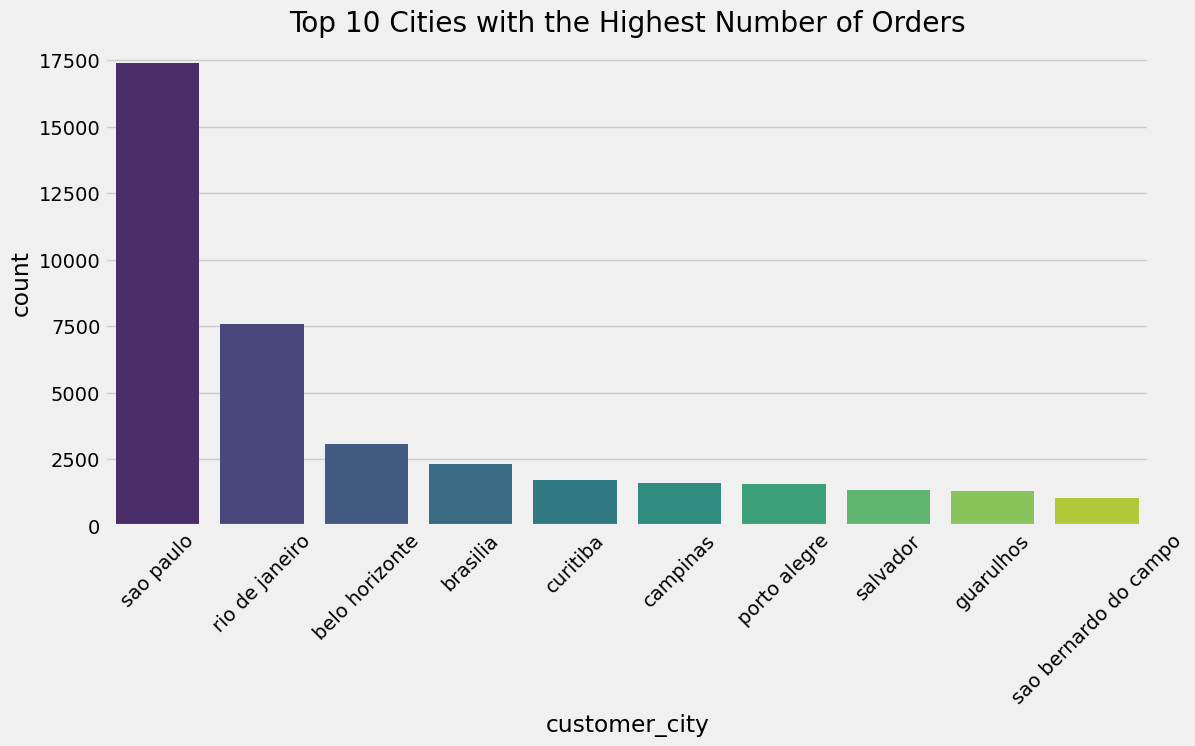

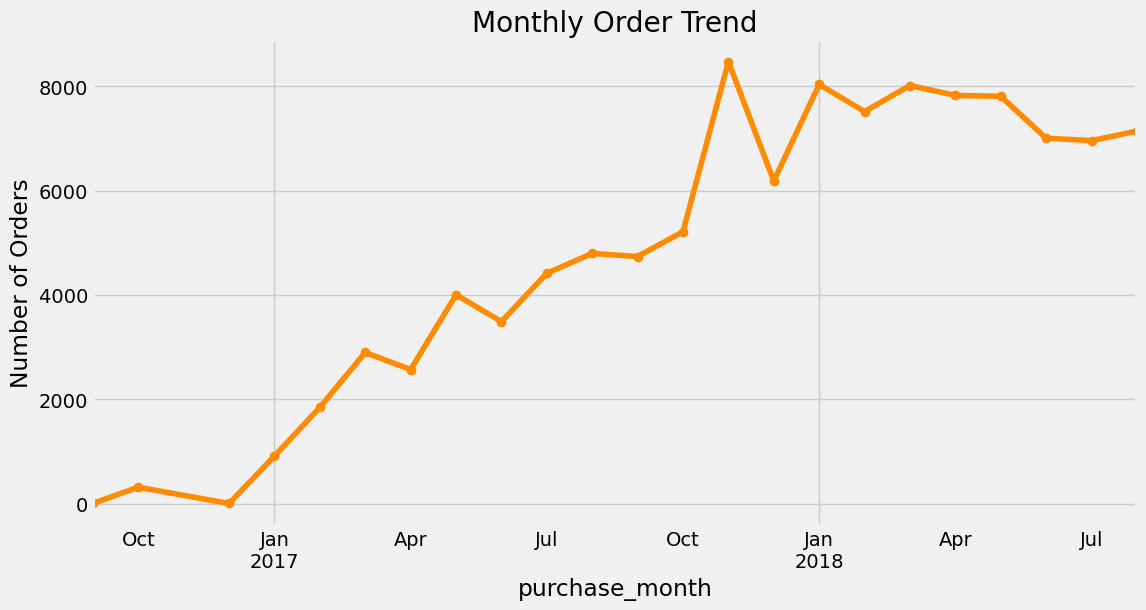

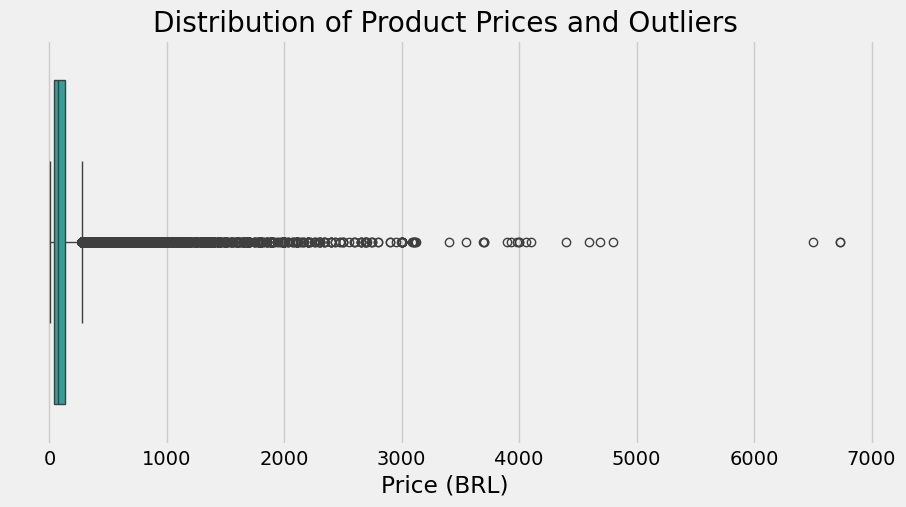

In [39]:
# Grafiklerin düzgün görünmesi için ayar
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 6)

# 9. En Çok Sipariş Verilen İlk 10 Şehir
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='customer_city', 
              order=df['customer_city'].value_counts().iloc[:10].index, 
              palette='viridis')
plt.title('Top 10 Cities with the Highest Number of Orders')
plt.xticks(rotation=45)
plt.show()

# 10. Aylık Sipariş Trendi
plt.figure(figsize=(12, 6))
df.groupby('purchase_month').size().plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Order Trend')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.show()

# 11. Harcama Miktarlarındaki Aykırı Değerler (Outliers)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'], color='lightseagreen')
plt.title('Distribution of Product Prices and Outliers')
plt.xlabel('Price (BRL)')
plt.show()

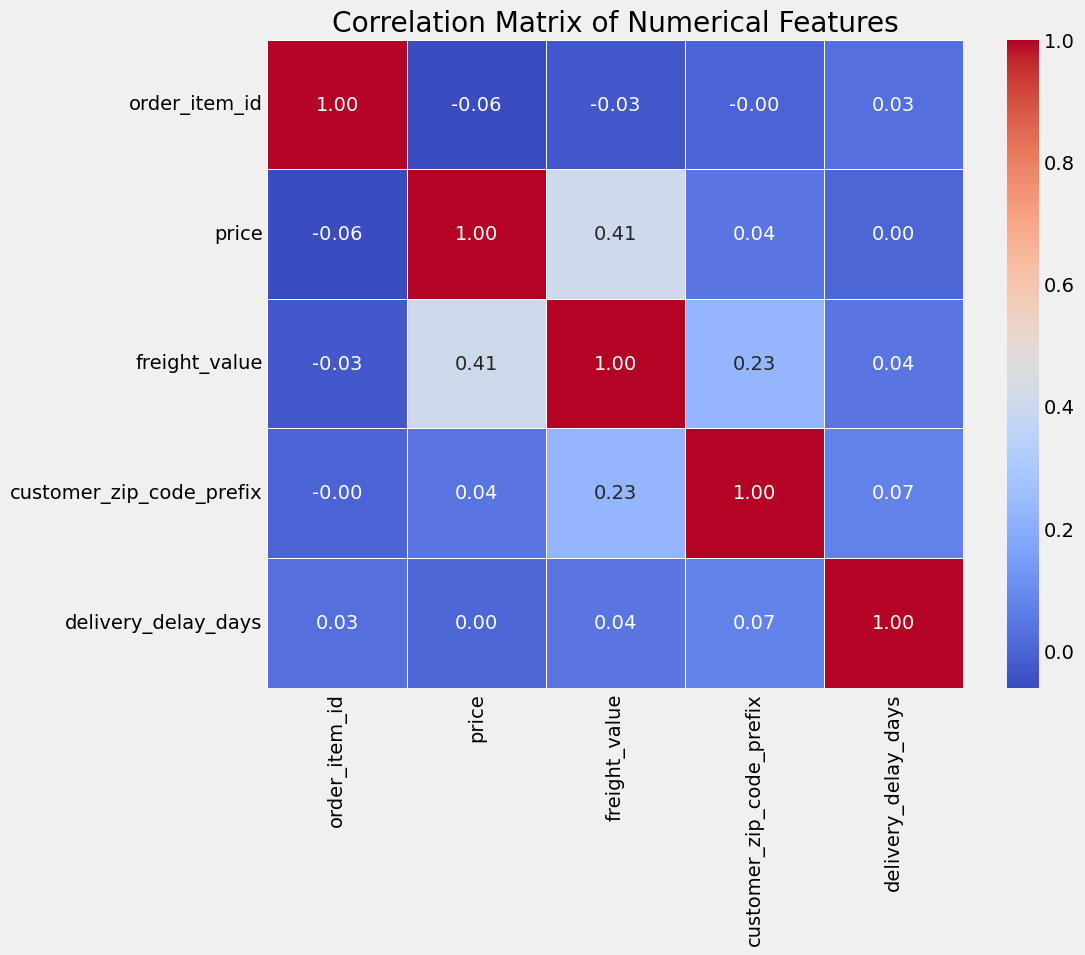

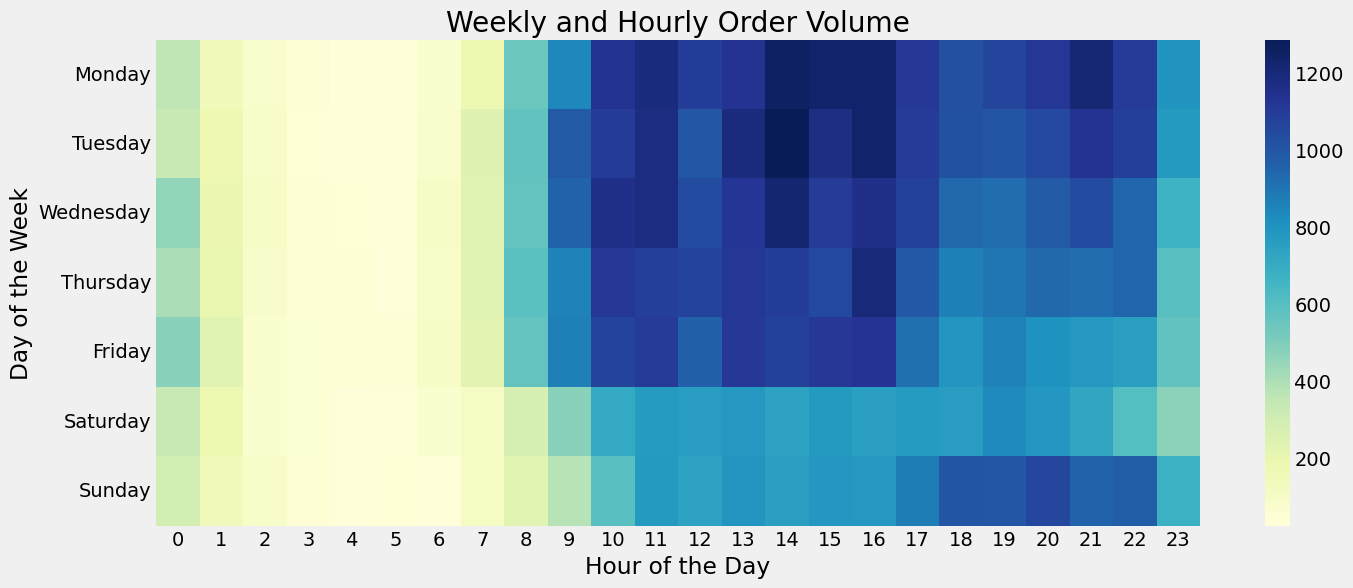

In [40]:
# 12. Korelasyon Matrisi (Isı Haritası)
# Sadece sayısal sütunları alalım
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# 13. Haftalık ve Saatlik Alışveriş Alışkanlıkları (Heatmap)
# Sipariş saatini ve gününü çıkaralım
df['order_hour'] = df['order_purchase_timestamp'].dt.hour
df['order_day_name'] = df['order_purchase_timestamp'].dt.day_name()

# Günleri sıralayalım
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Pivot tablo oluşturma
day_hour_pivot = df.pivot_table(index='order_day_name', columns='order_hour', values='order_id', aggfunc='count').reindex(day_order)

plt.figure(figsize=(15, 6))
sns.heatmap(day_hour_pivot, cmap='YlGnBu')
plt.title('Weekly and Hourly Order Volume')
plt.xlabel('Hour of the Day')
plt.ylabel('Day of the Week')
plt.show()

In [41]:
# 14. RFM Analizi (Müşteri Segmentasyonu)
# Analiz anını 'bugün' olarak belirleyelim (Verideki son tarihten 1 gün sonrası)
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Müşteri bazında gruplama (Aggregation)
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                             # Frequency
    'price': 'sum'                                                     # Monetary
})

# Sütun isimlerini düzenleyelim
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# İlk 5 müşteriye bakalım
print("--- RFM Tablosu (Müşteri Bazlı) ---")
print(rfm.head())

# İstatistiksel özet
print("\n--- RFM İstatistikleri ---")
print(rfm.describe())

--- RFM Tablosu (Müşteri Bazlı) ---
                                  Recency  Frequency  Monetary
customer_unique_id                                            
0000366f3b9a7992bf8c76cfdf3221e2      112          1    129.90
0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     18.90
0000f46a3911fa3c0805444483337064      537          1     69.00
0000f6ccb0745a6a4b88665a16c9f078      321          1     25.99
0004aac84e0df4da2b147fca70cf8255      288          1    180.00

--- RFM İstatistikleri ---
            Recency     Frequency      Monetary
count  93337.000000  93337.000000  93337.000000
mean     237.904893      1.033417    141.622063
std      152.552478      0.209096    215.713022
min        1.000000      1.000000      0.850000
25%      114.000000      1.000000     47.650000
50%      219.000000      1.000000     89.700000
75%      346.000000      1.000000    154.700000
max      714.000000     15.000000  13440.000000


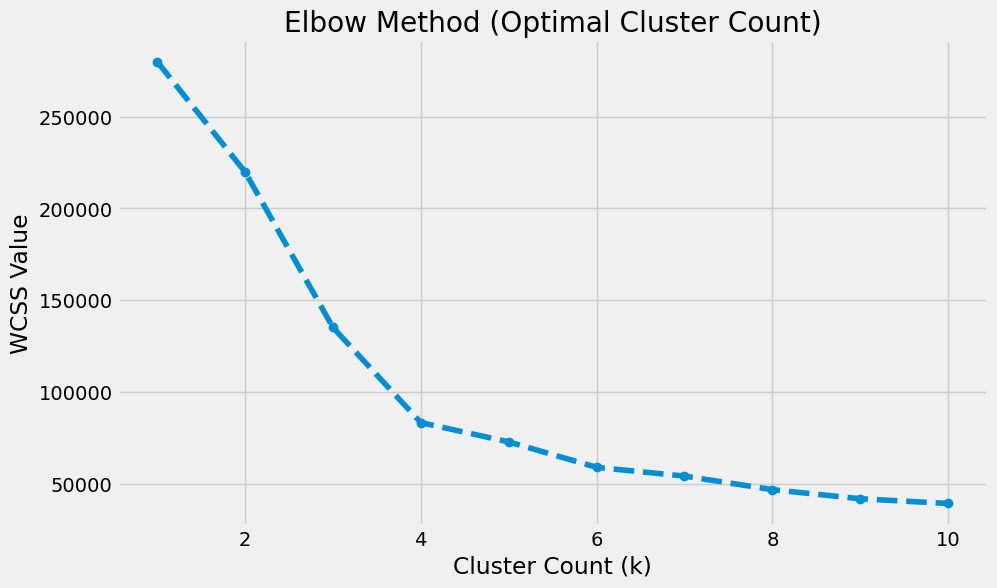

In [42]:
# 15. Log Transformation (np.log1p kullanarak log(x+1) yapıyoruz)
# Frequency ve Monetary için kritik, Recency için de dağılımı düzeltir.
rfm_log = np.log1p(rfm)

# 16. Scaling (Standardizasyon)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Ölçeklenmiş veriyi tekrar DataFrame yapalım (Kontrol için)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

# 17. Elbow Method (Optimal K sayısını bulma)
wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Grafiği Çizdirelim
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method (Optimal Cluster Count)')
plt.xlabel('Cluster Count (k)')
plt.ylabel('WCSS Value')
plt.show()

In [43]:
# 18. K-Means modelini 4 küme ile çalıştıralım
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_transform(rfm_scaled_df).argmin(axis=1) # Scaled veriden öğren, ham veriye yaz

# Kümeler 0'dan başladığı için 1-4 arasına çekelim (Daha okunaklı olur)
rfm['Cluster'] = rfm['Cluster'] + 1

# Her kümenin ortalama RFM değerlerine bakalım
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Customer_Count'})

print("--- Küme Bazlı RFM Analizi ---")
print(cluster_analysis.sort_values(by='Monetary', ascending=False))

--- Küme Bazlı RFM Analizi ---
            Recency  Frequency    Monetary  Customer_Count
Cluster                                                   
3        220.264286   2.113929  260.048589            2800
1        277.947594   1.000000  237.203063           37744
2         41.859637   1.000000  116.884633           16094
4        284.041691   1.000000   45.132258           36699


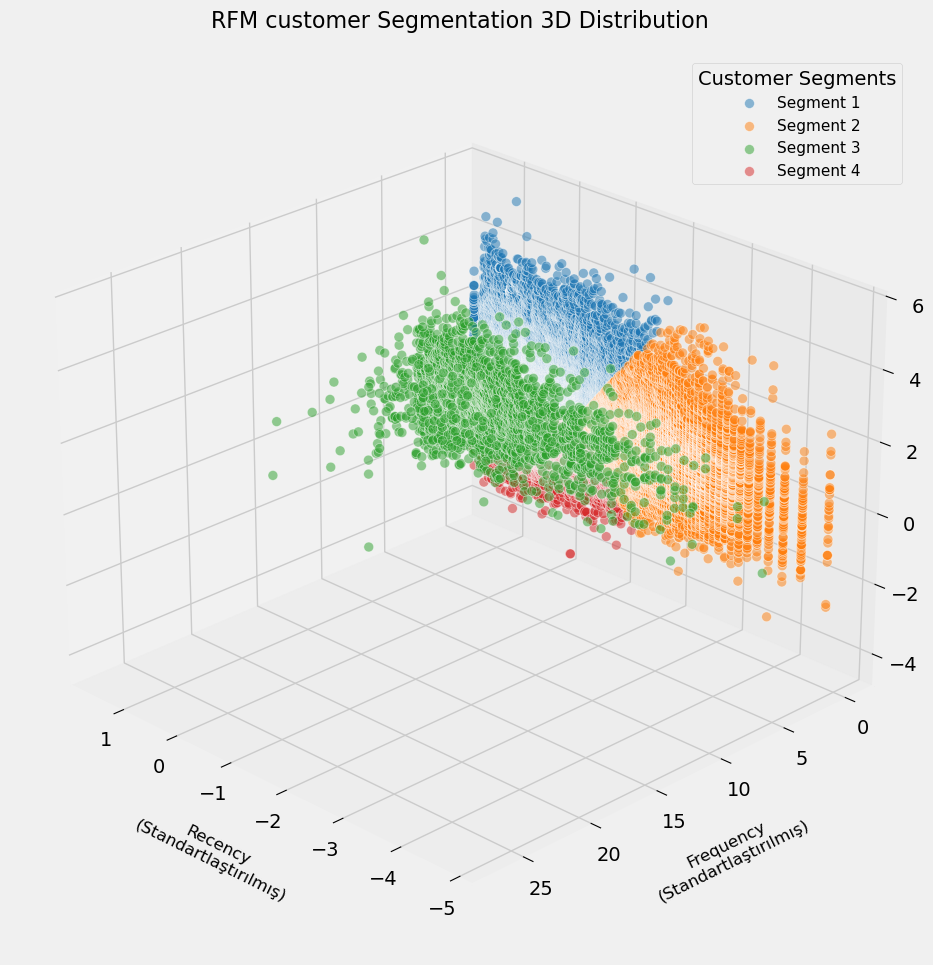

In [44]:
# 19.Grafik 
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Renk ve Küme Eşleşmesi
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
clusters = [1, 2, 3, 4]

# Veri Çizimi
for cluster, color in zip(clusters, colors):
    cluster_data = rfm_scaled_df[rfm['Cluster'] == cluster]
    ax.scatter(cluster_data['Recency'], 
               cluster_data['Frequency'], 
               cluster_data['Monetary'], 
               c=color, 
               label=f'Segment {cluster}', 
               s=50, 
               alpha=0.5, 
               edgecolors='w',
               linewidth=0.5)

# Eksen Etiketlerini Uzaklaştıralım (labelpad) ve Boyutlandıralım
ax.set_xlabel('\nRecency\n(Standartlaştırılmış)', fontsize=12, labelpad=15)
ax.set_ylabel('\nFrequency\n(Standartlaştırılmış)', fontsize=12, labelpad=15)
ax.set_zlabel('\nMonetary\n(Standartlaştırılmış)', fontsize=12, labelpad=20)

# Başlık ve Lejant
ax.set_title('RFM customer Segmentation 3D Distribution', fontsize=16, pad=20)
ax.legend(loc='upper right', fontsize=11, title="Customer Segments")

# 3D Grafik Görüş Açısı (Camera Angle) Ayarı
ax.view_init(elev=25, azim=135)

# Sıkışıklığı Önlemek İçin Manuel Boşluk Ayarı
plt.subplots_adjust(left=0, right=1, bottom=0, top=0.9)
plt.show()

#Grafikteki Eksenlerin Anlamı:
#Alt-Sağ Eksen (X): Recency (Müşterinin son alışverişinden beri geçen süre).

#Alt-Sol Eksen (Y): Frequency (Müşterinin toplam alışveriş sıklığı).

#Dikey Eksen (Z): Monetary (Müşterinin bıraktığı toplam parasal değer).

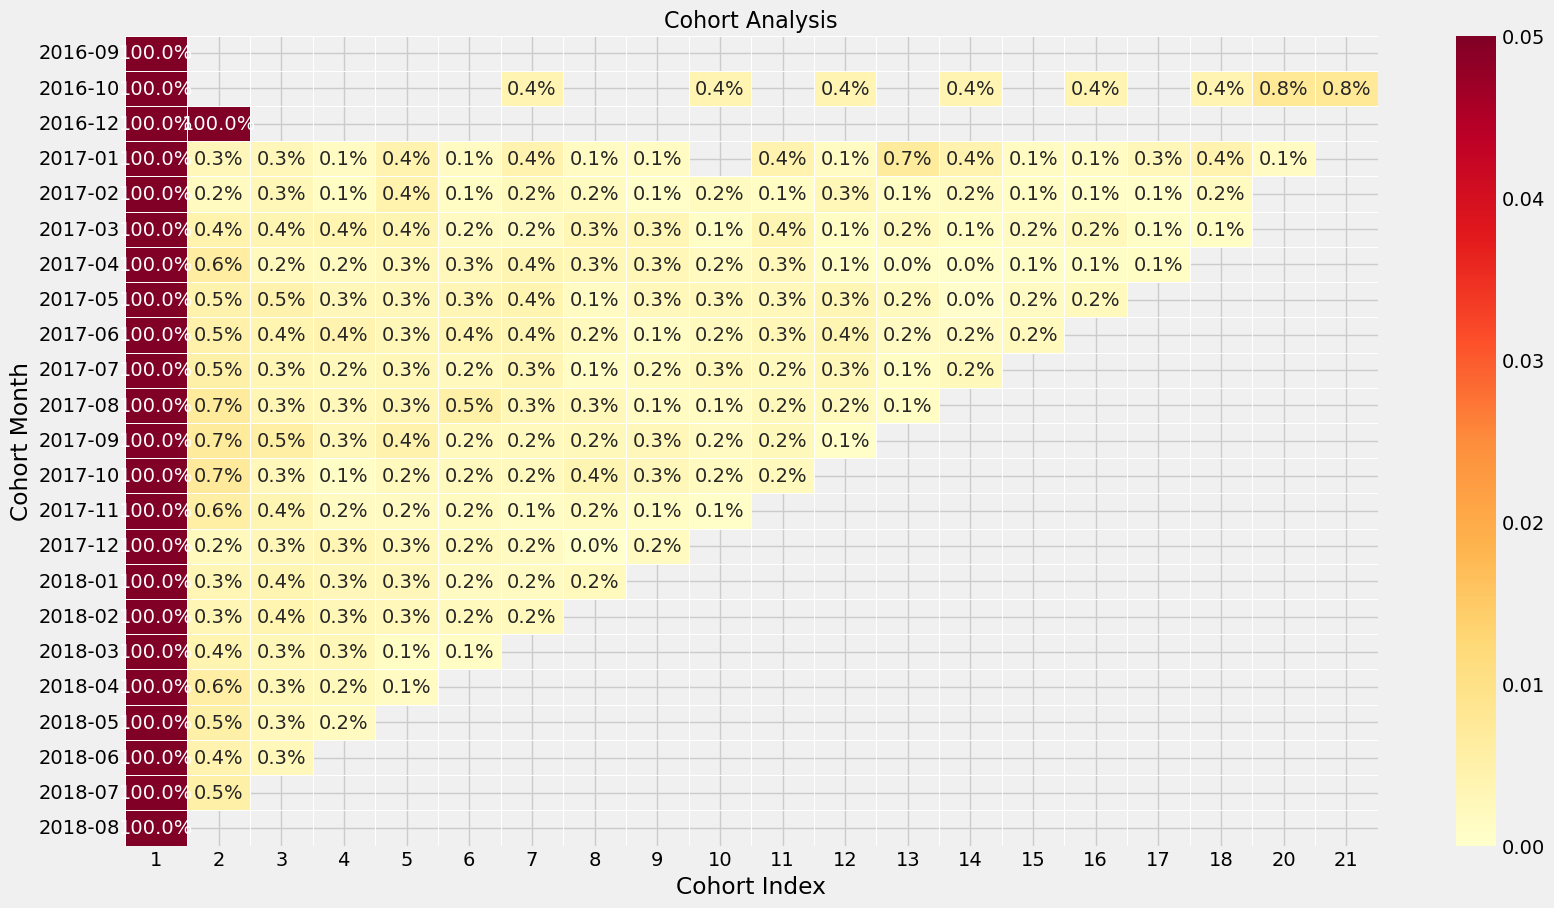

In [45]:
# 20. Cohort Analizi (Müşteri Elde Tutma Oranları)
# Ham df üzerinden gerekli kolonları alalım
# (Sipariş tarihi ve Müşteri ID'si bize yeterli)
cohort_data = df[['customer_unique_id', 'order_purchase_timestamp']].copy()

# Sipariş tarihlerini 'Ay' bazında yuvarlayalım (Günü 1 yapıyoruz)
def get_month(x): return dt.datetime(x.year, x.month, 1)
cohort_data['OrderMonth'] = cohort_data['order_purchase_timestamp'].apply(get_month)

# 3. Her müşterinin İLK alışveriş yaptığı ayı (Cohort Ayı) bulalım
cohort_data['CohortMonth'] = cohort_data.groupby('customer_unique_id')['OrderMonth'].transform('min')

# Yıl ve Ay farklarını hesaplayarak "Kaçıncı Ayında?" (Cohort Index) bulalım
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

order_year, order_month = get_date_int(cohort_data, 'OrderMonth')
cohort_year, cohort_month = get_date_int(cohort_data, 'CohortMonth')

years_diff = order_year - cohort_year
months_diff = order_month - cohort_month

# +1 ekliyoruz ki ilk alışveriş yapılan ay "1. Ay" olarak görünsün
cohort_data['CohortIndex'] = years_diff * 12 + months_diff + 1

# Cohort Tablosunu Oluşturma (Müşteri Sayılarını Sayma)
cohort_counts = cohort_data.groupby(['CohortMonth', 'CohortIndex'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index='CohortMonth', columns='CohortIndex', values='customer_unique_id')

# Retention Rate (Elde Tutma Oranı) Hesaplama
# Her satırı (ay grubunu), kendi ilk ayındaki müşteri sayısına bölüyoruz
cohort_sizes = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_sizes, axis=0)
retention.index = retention.index.strftime('%Y-%m') # İndeksi YYYY-MM formatına çevirelim

# Görselleştirme (Isı Haritası - Heatmap)
plt.figure(figsize=(18, 10))
plt.title('Cohort Analysis', fontsize=16)

sns.heatmap(data=retention, 
            annot=True, 
            fmt='.1%',       # Yüzde formatında göstersin
            vmin=0.0, 
            vmax=0.05,       # Maksimum %5 yapıyoruz ki renkler belirginleşsin (Olist'te dönüş çok düşüktür)
            cmap='YlOrRd',   # Sarıdan Kırmızıya renk paleti
            linewidths=0.5)

plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index')
plt.show()

In [46]:
# 21. Silhouette Score (Silüet Katsayısı)
# GLOBAL ÖRNEKLEM (Tüm algoritmalar tamamen aynı 10.000 kişiyle teste girecek)
np.random.seed(42) # Bilimsellik için hep aynı 10 bin kişiyi sabitler
global_sample_idx = np.random.choice(rfm_scaled_df.shape[0], 10000, replace=False)

sample_size = 10000

# Temel K-Means global indekslerle sınava giriyor
sil_score = silhouette_score(rfm_scaled_df.values[global_sample_idx], rfm['Cluster'].values[global_sample_idx])

# Davies-Bouldin Index (Tüm veri ile hesaplanır)
db_index = davies_bouldin_score(rfm_scaled_df, rfm['Cluster'])

print("--- Kümeleme Başarı Metrikleri ---")
print(f"Silhouette Score (n={sample_size}): {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_index:.4f}")
print(f"Final WCSS (Inertia): {kmeans.inertia_:.2f}")

--- Kümeleme Başarı Metrikleri ---
Silhouette Score (n=10000): 0.3847
Davies-Bouldin Index: 0.7584
Final WCSS (Inertia): 83272.23


In [47]:
# 22. Gelişmiş Model (Feature Engineering)
# Yeni Özelliklerin Eklenmesi (Feature Engineering)
advanced_features = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                             # Frequency
    'price': 'sum',                                                    # Monetary
    'freight_value': 'mean',                                           # Lojistik Maliyet
    'delivery_delay_days': 'mean'                                      # Müşteri Deneyimi (Gecikme)
})

# Sütun isimlerini netleştirelim
advanced_features.columns = ['Recency', 'Frequency', 'Monetary', 'Avg_Freight', 'Avg_Delay']

# Log Transformation
# Sağa çarpık (skewed) olan finansal ve frekans verilerini yumuşatalım
# Not: Avg_Delay negatif olabileceği için ona log uygulamıyoruz.
for col in ['Recency', 'Frequency', 'Monetary', 'Avg_Freight']:
    advanced_features[col] = np.log1p(advanced_features[col])

# Scaling (Ölçeklendirme)
scaler_adv = StandardScaler()
features_scaled_adv = scaler_adv.fit_transform(advanced_features)


# K-Means (k=4 sabit tutularak yeni veride kümeleme)
kmeans_adv = KMeans(n_clusters=4, init='k-means++', random_state=42)
advanced_clusters = kmeans_adv.fit_predict(features_scaled_adv)

# Yeni Başarı Metriklerinin Hesaplanması
# Örneklem üzerinden Silhouette skoru (Hız için)
sil_adv = silhouette_score(features_scaled_adv[global_sample_idx], advanced_clusters[global_sample_idx])
db_adv = davies_bouldin_score(features_scaled_adv, advanced_clusters)

print("\n--- Gelişmiş Model Metriği ---")
print(f"Silhouette Score: {sil_adv:.4f}")

# Karşılaştırma için kümelerin dağılımını görelim
unique, counts = np.unique(advanced_clusters, return_counts=True)
print("\nKüme Dağılımı (Müşteri Sayıları):")
print(dict(zip(unique + 1, counts)))


--- Gelişmiş Model Metriği ---
Silhouette Score: 0.2482

Küme Dağılımı (Müşteri Sayıları):
{1: 29100, 2: 14524, 3: 46913, 4: 2800}


In [48]:
# 23. Oransal Model
# Mevcut df üzerinden Freight / Price oranını bulalım
df['freight_ratio'] = df['freight_value'] / df['price']

# Müşteri bazında özetleyelim
ratio_features = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'price': 'sum',                                                    # Monetary
    'freight_ratio': 'mean'                                            # Davranışsal Oran
})
ratio_features.columns = ['Recency', 'Monetary', 'Avg_Freight_Ratio']

# Logaritma ve Ölçekleme (Freight ratio'ya log almıyoruz, zaten küçük bir oran)
ratio_features['Recency'] = np.log1p(ratio_features['Recency'])
ratio_features['Monetary'] = np.log1p(ratio_features['Monetary'])

scaler_ratio = StandardScaler()
ratio_scaled = scaler_ratio.fit_transform(ratio_features)

# K-Means (k=4)
kmeans_ratio = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters_ratio = kmeans_ratio.fit_predict(ratio_scaled)

# Örneklem üzerinden Silhouette skoru
sil_ratio = silhouette_score(ratio_scaled[global_sample_idx], clusters_ratio[global_sample_idx])

print("Oransal Model (Recency, Monetary, Freight Ratio) ")
print(f"Silhouette Score: {sil_ratio:.4f}")

Oransal Model (Recency, Monetary, Freight Ratio) 
Silhouette Score: 0.3225


In [49]:
# 24. Sadece Recency ve Monetary - RM Modeli
rm_features = rfm[['Recency', 'Monetary']].copy()

# Logaritma ve Ölçekleme
rm_features['Recency'] = np.log1p(rm_features['Recency'])
rm_features['Monetary'] = np.log1p(rm_features['Monetary'])

scaler_rm = StandardScaler()
rm_scaled = scaler_rm.fit_transform(rm_features)

# K-Means (k=4)
kmeans_rm = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters_rm = kmeans_rm.fit_predict(rm_scaled)

# Örneklem üzerinden Silhouette skoru
sil_rm = silhouette_score(rm_scaled[global_sample_idx], clusters_rm[global_sample_idx])

print("RM Modeli (Sadece Recency ve Monetary)")
print(f"Silhouette Score: {sil_rm:.4f}")

RM Modeli (Sadece Recency ve Monetary)
Silhouette Score: 0.3381


In [50]:
# 25. Diğer Algoritmalar 

# Tüm veriyi kullanıyoruz (Eğitim için)
rfm_full = rfm_scaled_df.values

# Algoritmaları Tanımlayalım
algorithms = {
    "GMM (Eliptik Dağılım)": GaussianMixture(n_components=4, random_state=42),
    "DBSCAN (Yoğunluk)": DBSCAN(eps=0.5, min_samples=10)
}

results = []
saved_labels = {} 

for name, algo in algorithms.items():
    start_time = time.time()

    try:
        # Algoritma eğitimi ve etiket tahmini
        labels = algo.fit_predict(rfm_full)
        
        # Eğitilmiş etiketleri ismine göre hafızaya (sözlüğe) kaydet
        saved_labels[name] = labels
            
        elapsed = time.time() - start_time
        
        # DBSCAN için özel kontroller
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = list(labels).count(-1) / len(labels) if -1 in labels else 0.0
        
        # Metrik Hesaplamaları
        if n_clusters > 1:
            # Performans Optimizasyonu: Metrikler 10.000'lik sabit örneklem (global_sample_idx) üzerinden hesaplanmıştır.
            sil = silhouette_score(rfm_full[global_sample_idx], labels[global_sample_idx])
            
            # DB ve CH metrikleri O(N) karmaşıklığında olduğu için tüm veriyle hızlıca hesaplanabilir. Tutarlılığı koruyoruz.
            db = davies_bouldin_score(rfm_full, labels)
            ch = calinski_harabasz_score(rfm_full, labels)
        else:
            sil, db, ch = -1, -1, -1
        
        results.append({
            "Algoritma": name,
            "Durum": "BAŞARILI",
            "Küme": n_clusters,
            "Gürültü": f"%{noise_ratio*100:.1f}",
            "Silhouette": round(sil, 4),
            "DB Index": round(db, 4),
            "CH Score": round(ch, 2),
            "Süre (sn)": round(elapsed, 2)
        })
        print(f" {name} başarıyla tamamlandı. (Süre: {elapsed:.1f} sn)\n")
    except Exception as e:
        results.append({
            "Algoritma": name,
            "Durum": f"HATA: {str(e)}",
            "Küme": "-",
            "Gürültü": "-",
            "Silhouette": "-",
            "DB Index": "-",
            "CH Score": "-",
            "Süre (sn)": "-"
        })
        print(f" {name} çalıştırılırken hata oluştu: {str(e)}\n")

# Sonuçları Tablolama
benchmark_df = pd.DataFrame(results)

print("TÜM VERİ (FULL DATASET) ALTERNATİF ALGORİTMALAR TABLOSU")
print(benchmark_df.to_string(index=False))

 GMM (Eliptik Dağılım) başarıyla tamamlandı. (Süre: 1.5 sn)

 DBSCAN (Yoğunluk) başarıyla tamamlandı. (Süre: 25.6 sn)

TÜM VERİ (FULL DATASET) ALTERNATİF ALGORİTMALAR TABLOSU
            Algoritma    Durum  Küme Gürültü  Silhouette  DB Index  CH Score  Süre (sn)
GMM (Eliptik Dağılım) BAŞARILI     4    %0.0      0.3711    0.7794  70286.38       1.48
    DBSCAN (Yoğunluk) BAŞARILI     4    %0.1      0.6925    5.1687  11500.52      25.62


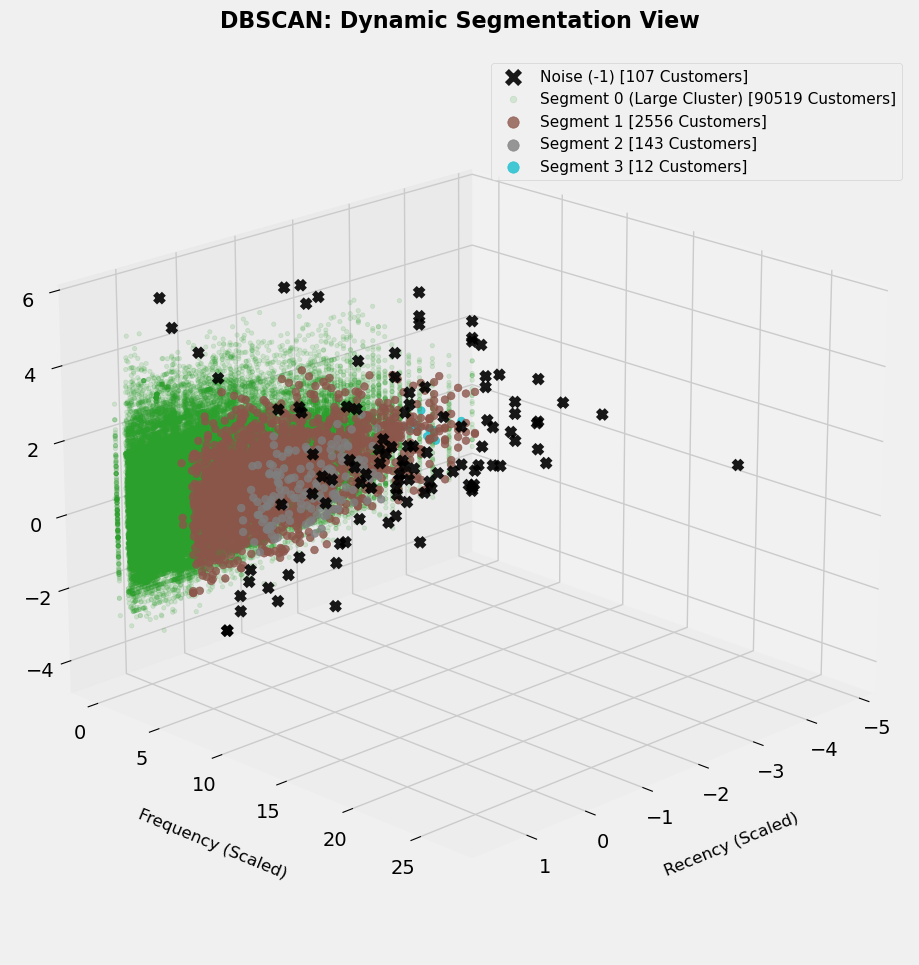

In [51]:
# 26. DBSCAN Sonuçlarının Dinamik Görselleştirilmesi
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Döngüden çıkan son algoritmamız DBSCAN olduğu için 'labels' değişkeni 
# doğrudan 93.337 verinin etiketlerini barındırır.
viz_data = rfm_full 
viz_labels = saved_labels["DBSCAN (Yoğunluk)"] # BÖYLE YAZ

# Eşsiz etiketleri ve her bir etikete düşen kişi sayısını dinamik alıyoruz
unique_labels, label_counts = np.unique(viz_labels, return_counts=True)

# Kümeler için dinamik renk paleti (Gürültü hariç)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = (viz_labels == label)
    count = label_counts[i] 
    
    if label == -1:
        # Gürültü noktaları
        c = 'black'
        m = 'x'
        label_name = f'Noise (-1) [{count} Customers]'
        s = 40
        alpha = 0.9
    else:
        # Küme noktaları
        c = colors[i]
        m = 'o'
        # Yığın çok büyükse şeffaflığı artırıyoruz (Arkada kalanlar yutulmasın)
        if count > 10000:
            label_name = f'Segment {label} (Large Cluster) [{count} Customers]'
            s = 10
            alpha = 0.15 
        else:
            label_name = f'Segment {label} [{count} Customers]'
            s = 30 
            alpha = 0.8 

    ax.scatter(viz_data[mask, 0], viz_data[mask, 1], viz_data[mask, 2], 
               color=c, marker=m, s=s, alpha=alpha, label=label_name)

# Eksen İsimleri
ax.set_xlabel('\nRecency (Scaled)', fontsize=12, labelpad=15)
ax.set_ylabel('\nFrequency (Scaled)', fontsize=12, labelpad=15)
ax.set_zlabel('\nMonetary (Scaled)', fontsize=12, labelpad=15)

# Görüş Açısı
ax.view_init(elev=20, azim=45)

ax.set_title('DBSCAN: Dynamic Segmentation View', fontsize=16, fontweight='bold', pad=20)

# Legend (Açıklama Kutusu)
ax.legend(markerscale=1.5, loc='upper right', fontsize=11)

plt.subplots_adjust(left=0, right=1, bottom=0, top=0.9)
plt.show()

In [52]:
# 27. DBSCAN sonuçlarrı
# unique, counts = np.unique(labels, return_counts=True) <-- BUNU SİL
unique, counts = np.unique(saved_labels["DBSCAN (Yoğunluk)"], return_counts=True) # BÖYLE YAZ

dbscan_summary = pd.DataFrame({
    'Küme ID': unique,
    'Müşteri Sayısı': counts,
    'Yüzde (%)': (counts / len(saved_labels["DBSCAN (Yoğunluk)"]) * 100).round(2) # BURAYI DA GÜNCELLE
})

# ID'leri daha anlaşılır isimlendir
dbscan_summary['Açıklama'] = dbscan_summary['Küme ID'].apply(
    lambda x: 'Gürültü (Dışlanan VIP)' if x == -1 else f'Segment {x}'
)

# Tabloyu göster
print("=== DBSCAN TÜM VERİ (93.337) SEGMENTASYON ÖZETİ ===")
print(dbscan_summary[['Küme ID', 'Açıklama', 'Müşteri Sayısı', 'Yüzde (%)']].to_string(index=False))

=== DBSCAN TÜM VERİ (93.337) SEGMENTASYON ÖZETİ ===
 Küme ID               Açıklama  Müşteri Sayısı  Yüzde (%)
      -1 Gürültü (Dışlanan VIP)             107       0.11
       0              Segment 0           90519      96.98
       1              Segment 1            2556       2.74
       2              Segment 2             143       0.15
       3              Segment 3              12       0.01


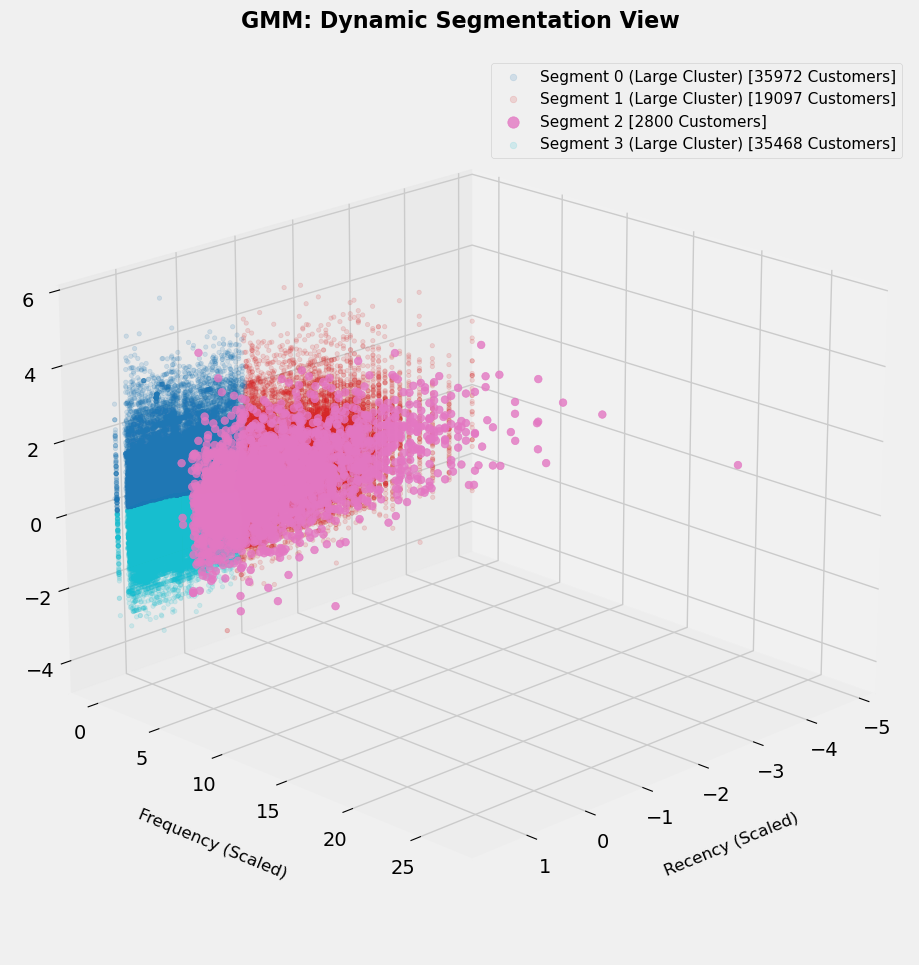

In [53]:
# 28. GMM Sonuçlarının Dinamik Görselleştirilmesi

# GMM etiketleri yeniden eğitilmek yerine bellekten (saved_labels) çağrılmaktadır.
gmm_labels = saved_labels["GMM (Eliptik Dağılım)"]

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

viz_data = rfm_full
viz_labels = gmm_labels

# Eşsiz etiketleri ve her bir kümeye düşen kişi sayısını dinamik alıyoruz (0, 1, 2, 3)
unique_labels, label_counts = np.unique(viz_labels, return_counts=True)

# Kümeler için dinamik renk paleti
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = (viz_labels == label)
    count = label_counts[i]
    
    # Otomatik renk ve işaretçi ataması
    c = colors[i]
    m = 'o'
    
    # Çok büyük yığınlar için şeffaflık ayarı (Örtüşmeyi/Overlapping'i yönetmek adına)
    if count > 10000:
        label_name = f'Segment {label} (Large Cluster) [{count} Customers]'
        s = 10
        alpha = 0.15
    else:
        label_name = f'Segment {label} [{count} Customers]'
        s = 30
        alpha = 0.8

    ax.scatter(viz_data[mask, 0], viz_data[mask, 1], viz_data[mask, 2], 
               color=c, marker=m, s=s, alpha=alpha, label=label_name)

# Eksen İsimleri
ax.set_xlabel('\nRecency (Scaled)', fontsize=12, labelpad=15)
ax.set_ylabel('\nFrequency (Scaled)', fontsize=12, labelpad=15)
ax.set_zlabel('\nMonetary (Scaled)', fontsize=12, labelpad=15)

# Görüş Açısı (K-Means ve DBSCAN ile aynı ferah bakış açısı)
ax.view_init(elev=20, azim=45)

ax.set_title('GMM: Dynamic Segmentation View', fontsize=16, fontweight='bold', pad=20)

# Legend (Açıklama Kutusu)
ax.legend(markerscale=1.5, loc='upper right', fontsize=11)

plt.subplots_adjust(left=0, right=1, bottom=0, top=0.9)
plt.show()

In [54]:
# 29. GMM sonuçları
unique, counts = np.unique(gmm_labels, return_counts=True)

# Şık bir Pandas DataFrame oluştur
gmm_summary = pd.DataFrame({
    'Küme ID': unique,
    'Müşteri Sayısı': counts,
    'Yüzde (%)': (counts / len(gmm_labels) * 100).round(2)
})

# Akademik raporlama için açıklamaları isimlendir
gmm_summary['Açıklama'] = gmm_summary['Küme ID'].apply(lambda x: f'GMM Bileşeni (Segment) {x}')

# Tabloyu ekrana bas
print("=== GMM TÜM VERİ (93.337) SEGMENTASYON ÖZETİ ===")
print(gmm_summary[['Küme ID', 'Açıklama', 'Müşteri Sayısı', 'Yüzde (%)']].to_string(index=False))

=== GMM TÜM VERİ (93.337) SEGMENTASYON ÖZETİ ===
 Küme ID                 Açıklama  Müşteri Sayısı  Yüzde (%)
       0 GMM Bileşeni (Segment) 0           35972      38.54
       1 GMM Bileşeni (Segment) 1           19097      20.46
       2 GMM Bileşeni (Segment) 2            2800       3.00
       3 GMM Bileşeni (Segment) 3           35468      38.00


In [55]:
# 30. Sonuçların Raporlanması (Tablo ve Özet)
def get_cluster_distribution(cluster_array, is_dbscan=False):
    unique_vals, counts = np.unique(cluster_array, return_counts=True)
    total_obs = len(cluster_array)
    distribution_list = []
    
    for val, count in zip(unique_vals, counts):
        percentage = (count / total_obs) * 100
        
        # DBSCAN için -1 etiketini Noise (Gürültü) olarak ayır
        if is_dbscan and val == -1:
            distribution_list.append(f"Noise: {count} ({percentage:.1f}%)")
        else:
            distribution_list.append(f"Seg {val}: {count} ({percentage:.1f}%)")
            
    return " | ".join(distribution_list)

# Hafızadaki mevcut değişkenlerden (önceden hesaplanmış) verileri çekerek tabloyu oluşturuyoruz
final_summary = [
    {
        "Algorithm / Model Setup": "1. Baseline K-Means (RFM 3D)",
        "Silhouette Score": round(sil_score, 4),
        "Cluster Distribution (Count & %)": get_cluster_distribution(rfm['Cluster'])
    },
    {
        "Algorithm / Model Setup": "2. K-Means (Logistics)",
        "Silhouette Score": round(sil_adv, 4),
        "Cluster Distribution (Count & %)": get_cluster_distribution(advanced_clusters)
    },
    {
        "Algorithm / Model Setup": "3. K-Means (Freight Ratio)",
        "Silhouette Score": round(sil_ratio, 4),
        "Cluster Distribution (Count & %)": get_cluster_distribution(clusters_ratio)
    },
    {
        "Algorithm / Model Setup": "4. K-Means  (RM Only - No Freq)",
        "Silhouette Score": round(sil_rm, 4),
        "Cluster Distribution (Count & %)": get_cluster_distribution(clusters_rm)
    },
    {
        "Algorithm / Model Setup": "5. Gaussian Mixture Model (GMM)",
        # GMM skorunu daha önce oluşturduğumuz benchmark_df tablosundan otomatik çekiyoruz
        "Silhouette Score": benchmark_df.loc[benchmark_df['Algoritma'] == 'GMM (Eliptik Dağılım)', 'Silhouette'].values[0],
        "Cluster Distribution (Count & %)": get_cluster_distribution(gmm_labels)
    },
{
        "Algorithm / Model Setup": "6. DBSCAN (Density-Based)",
        "Silhouette Score": benchmark_df.loc[benchmark_df['Algoritma'] == 'DBSCAN (Yoğunluk)', 'Silhouette'].values[0],
        "Cluster Distribution (Count & %)": get_cluster_distribution(saved_labels["DBSCAN (Yoğunluk)"], is_dbscan=True)
    }
]

# Pandas DataFrame'e çevir
final_report_df = pd.DataFrame(final_summary)

# Pandas'ın uzun metinleri (...) ile kesmesini engellemek için sütun genişliğini maksimum yapıyoruz
pd.set_option('display.max_colwidth', None)


print("FINAL ALGORITHMIC BENCHMARK & SEGMENT DISTRIBUTION SUMMARY")
print(final_report_df.to_string(index=False))

FINAL ALGORITHMIC BENCHMARK & SEGMENT DISTRIBUTION SUMMARY
        Algorithm / Model Setup  Silhouette Score                                                                     Cluster Distribution (Count & %)
   1. Baseline K-Means (RFM 3D)            0.3847              Seg 1: 37744 (40.4%) | Seg 2: 16094 (17.2%) | Seg 3: 2800 (3.0%) | Seg 4: 36699 (39.3%)
         2. K-Means (Logistics)            0.2482              Seg 0: 29100 (31.2%) | Seg 1: 14524 (15.6%) | Seg 2: 46913 (50.3%) | Seg 3: 2800 (3.0%)
     3. K-Means (Freight Ratio)            0.3225              Seg 0: 32090 (34.4%) | Seg 1: 8401 (9.0%) | Seg 2: 37435 (40.1%) | Seg 3: 15411 (16.5%)
4. K-Means  (RM Only - No Freq)            0.3381            Seg 0: 14862 (15.9%) | Seg 1: 37264 (39.9%) | Seg 2: 15826 (17.0%) | Seg 3: 25385 (27.2%)
5. Gaussian Mixture Model (GMM)            0.3711              Seg 0: 35972 (38.5%) | Seg 1: 19097 (20.5%) | Seg 2: 2800 (3.0%) | Seg 3: 35468 (38.0%)
      6. DBSCAN (Density-Based)    